In [2]:
import numpy as np
from sklearn.metrics import accuracy_score
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
x_train, x_val,y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

X_train [shape (48000, 28, 28)] sample patch:
 [[  0  77 254 154   0]
 [  0 145 253  96   0]
 [  0 254 238  37   0]
 [  0 254 229   0   0]
 [  0 254 246  69   0]]


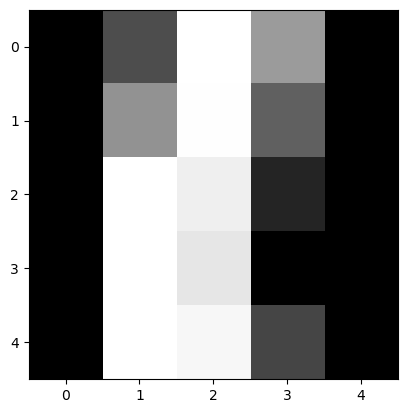

In [5]:
print("X_train [shape %s] sample patch:\n" % (str(x_train.shape)), x_train[1, 15:20, 5:10])
plt.imshow(x_train[1, 15:20, 5:10], cmap='gray')
plt.show()

In [6]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
#preprocessing data - scale the data
x_train = x_train.astype('float32') /255.0
x_test = x_test.astype('float32') /255.0
#reshape data
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)
#one hot encoding
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
model = tf.keras.Sequential([
    #creatae some of hidden layers
    tf.keras.layers.Dense(500, activation='sigmoid', input_shape=(784,)),
    tf.keras.layers.Dense(100, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

c:\Users\asus\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,610 (1.69 MB)

 Trainable params: 443,610 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train_oh, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8708 - loss: 0.4938 - val_accuracy: 0.9314 - val_loss: 0.2352
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9385 - loss: 0.2068 - val_accuracy: 0.9448 - val_loss: 0.1843
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9561 - loss: 0.1459 - val_accuracy: 0.9614 - val_loss: 0.1354
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9682 - loss: 0.1082 - val_accuracy: 0.9678 - val_loss: 0.1086
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9760 - loss: 0.0820 - val_accuracy: 0.9700 - val_loss: 0.0989
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9811 - loss: 0.0631 - val_accuracy: 0.9721 - val_loss: 0.0903
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9858 - loss: 0.0489 - val_accuracy: 0.9749 - val_loss: 0.0827
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9891 - loss: 0.0384 - val_accuracy: 0.

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9807 - loss: 0.0630
Test accuracy: 0.9807000160217285


In [9]:
def get_random_inices(n, total):
    return np.random.choice(total, n, replace=False)   
predictions = model.predict(x_test)
x_test_images = x_test.reshape(-1, 28, 28)
prediction_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test_oh, axis=1)



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [10]:
num_images = 5
random_indices = get_random_inices(num_images, len(x_test))
def plot_images(images, true_labels, pred_labels, indices):
    plt.figure(figsize=(15, 5))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f'True: {true_labels[i]}\nPred: {pred_labels[i]}')
        plt.axis('off')
plt.show()

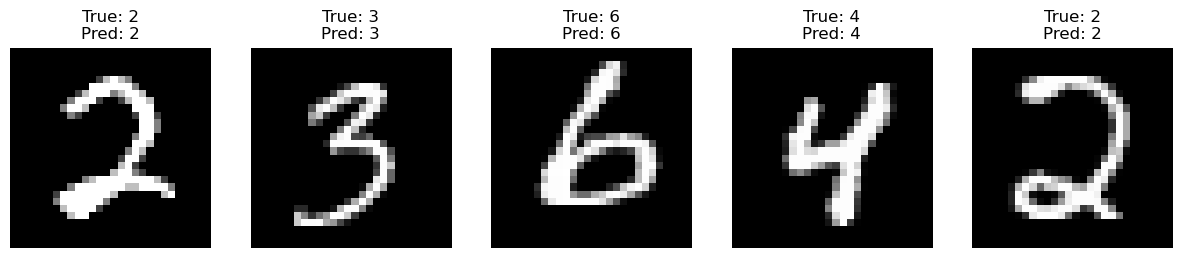

In [11]:
plot_images(
    x_test_images[random_indices],
    true_classes[random_indices],
    prediction_classes[random_indices],
    random_indices
)

In [12]:

from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import TensorBoard
name="mnist-28-28-1"
TensorBoard_callback = TensorBoard(log_dir="logs/{}".format(name))

(x_train, y_train), (x_test, y_test) = mnist.load_data()

#preprocessing data - scale the data

x_train = x_train.astype('float32') /255.0

x_test = x_test.astype('float32') /255.0

#reshape data

x_train = x_train.reshape(-1,784)

x_test = x_test.reshape(-1,784)

#one hot encoding

y_train_oh = tf.keras.utils.to_categorical(y_train, 10)

y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

model = tf.keras.Sequential([

   #creatae some of hidden layers

    tf.keras.layers.Dense(500, activation='sigmoid', input_shape=(784,)),

    tf.keras.layers.Dense(100, activation='sigmoid'),

    tf.keras.layers.Dense(10, activation='softmax')  

])

model.compile(optimizer= 'Adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train_oh, epochs=10, batch_size=64, validation_split=0.2)

test_loss, test_acc = model.evaluate(x_test, y_test_oh)

print('Test accuracy:', test_acc)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8775 - loss: 0.4742 - val_accuracy: 0.9290 - val_loss: 0.2377
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9387 - loss: 0.2071 - val_accuracy: 0.9518 - val_loss: 0.1719
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9558 - loss: 0.1485 - val_accuracy: 0.9597 - val_loss: 0.1354
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9674 - loss: 0.1111 - val_accuracy: 0.9657 - val_loss: 0.1152
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9746 - loss: 0.0854 - val_accuracy: 0.9699 - val_loss: 0.1002
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9809 - loss: 0.0657 - val_accuracy: 0.9714 - val_loss: 0.0992
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9848 - loss: 0.0511 - val_accuracy: 0.9740 - val_loss: 0.0844
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9886 - loss: 0.0401 - val_accuracy: 0.